# Extended Generalized Pareto Models for the Spatial Modeling of Extreme and Bulk Rainfall

Orla A. Murphy $^{1}$ and Jonathan Jalbert $^{2}$

$^{1}$ Dalhousie University  
$^{2}$ Polytechnique Montréal

June 15, 2026

This notebook reproduces the results presented in Murphy and Jalbert (2026).

The notebook runs with a Julia 1.12 kernel and uses the following package versions:

* Cairo v1.1.1
* CSV v0.10.16
* DataFrames v1.8.2
* Distributions v0.25.126
* Extremes v1.0.5
* ExtendedExtremes v0.3.2
* Fontconfig v0.4.1
* Gadfly v1.4.1
* Plots v1.41.6
* ProgressMeter v1.11.0

### Reference

Murphy, O. A. and Jalbert, J. (2026). Extended Generalized Pareto Models for the Spatial Modeling of Extreme and Bulk Rainfall. *Submitted to Environmetrics*.


In [1]:
using CSV, DataFrames
using Distributions, Extremes, ExtendedExtremes
using ProgressMeter, LinearAlgebra
import Plots
using Gadfly, Cairo, Fontconfig

### Utilities

In [2]:
function changerate(x::Vector{<:Real})
    
    n = length(x)
   
    c = count(diff(x) .≈ 0.)
    
    return (n-c)/n
    
end

function changerate(X::Matrix{<:Real})
    
    n = size(X,1)
   
    c = vec(count(diff(X,dims=1) .≈ 0., dims=1))
    
    return (n .- c)./n
    
end

changerate (generic function with 2 methods)

### Loading the data

In [3]:
covariate = CSV.read("loc_and_covariate.csv", DataFrame)
first(covariate, 5)

Row,Column1,lon,lat,x
,Int64,Float64,Float64,Float64
1,1,-61.97,45.63,3.93911
2,2,-65.63,44.57,3.96214
3,3,-63.72,44.9,4.21417
4,4,-65.3,44.83,3.82417
5,5,-65.78,43.58,4.54203


In [4]:
data = CSV.read("thresh_exc.csv", DataFrame, missingstring="NA")

y = Vector{Float64}[]

for i in 2:ncol(data)
    push!(y, collect(skipmissing(data[:,i])))
end

### Marginal fit of the EGP distribution

In [5]:
fd = [fit_mle(ExtendedGeneralizedPareto{TBeta}, yᵢ) for yᵢ in y]

κ̂ = first.(shape.(fd))
σ̂ = first.(ExtendedExtremes.scale.(fd))
ξ̂ = first.(tailindex.(fd));

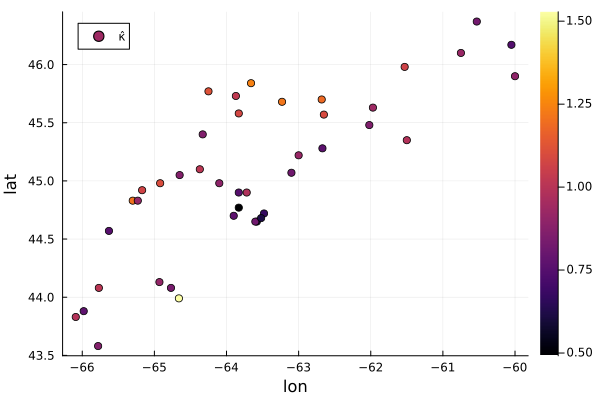

In [6]:
Plots.scatter(covariate.lon, covariate.lat, zcolor=κ̂, label="κ̂", xlabel="lon", ylabel="lat")

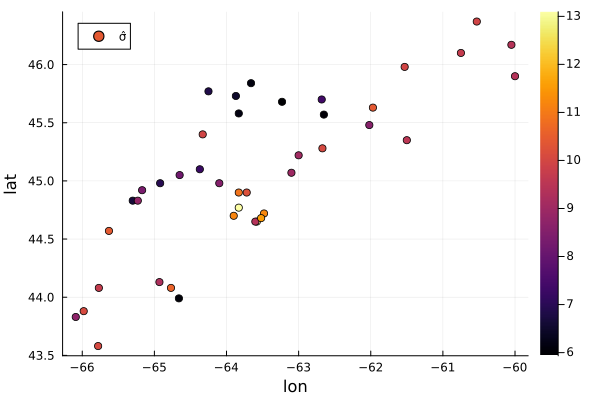

In [7]:
Plots.scatter(covariate.lon, covariate.lat, zcolor=σ̂, label="σ̂", xlabel="lon", ylabel="lat")

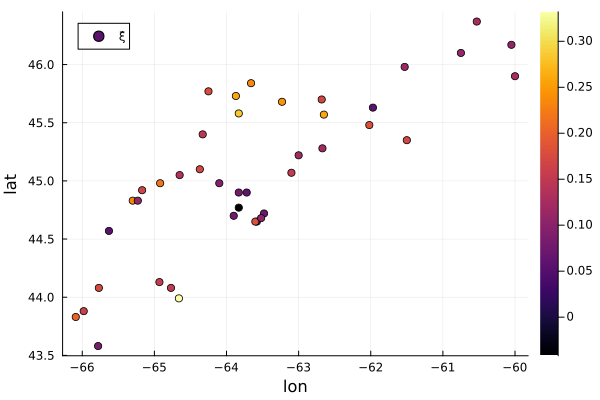

In [8]:
Plots.scatter(covariate.lon, covariate.lat, zcolor=ξ̂, label="ξ̂", xlabel="lon", ylabel="lat")

### Exploratory analysis

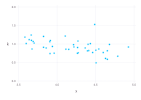

In [9]:
plot(x=covariate.x, y=κ̂, Geom.point, Guide.ylabel("κ̂"))

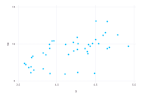

In [10]:
plot(x=covariate.x, y=σ̂, Geom.point, Guide.ylabel("σ̂"))

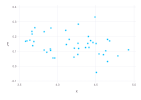

In [11]:
plot(x=covariate.x, y=ξ̂, Geom.point, Guide.ylabel("ξ̂"))

### Fitting the spatial model

- κ and σ as a linear function of the covariate
- Common ξ for all stations

In [12]:
function loglike(y::Vector{<:Real}, η::Real, ϕ::Real, ξ::Real)
    κ = exp(η)
    σ = exp(ϕ)
        
    pd = ExtendedGeneralizedPareto(TBeta(κ), GeneralizedPareto(σ, ξ))
        
    return sum(logpdf(pd, y))
end

loglike (generic function with 1 method)

In [ ]:
NITER = 20000
m = length(y)

x = (covariate.x .- mean(covariate.x))./std(covariate.x)

X = [ones(length(x)) x]

Q = X'X + I
V = inv(X'X +I)

η = Matrix{Float64}(undef, NITER, length(y))
ϕ = Matrix{Float64}(undef, NITER, length(y))
        
β₁ = Matrix{Float64}(undef, NITER, 2)
τ₁ = Vector{Float64}(undef, NITER)

β₂ = Matrix{Float64}(undef, NITER, 2)
τ₂ = Vector{Float64}(undef, NITER)

ξ = Vector{Float64}(undef, NITER)

η[1,:] = log.(first.(shape.(fd)))
ϕ[1,:] = log.(first.(ExtendedExtremes.scale.(fd)))

β₁[1,1] = mean(η[1,:])
β₁[1,2] = 0.
τ₁[1] = std(η[1,:]) 

β₂[1,1] = mean(ϕ[1,:])
β₂[1,2] = 0.
τ₂[1] = std(ϕ[1,:]) 

ξ[1] = 0.15

prior_xi = LocationScale(-.5, 1, Beta(9,6))

@showprogress for iter in 2:NITER
    
    for i in 1:m
       
        η̃ = η[iter-1,i] + randn()/5
        
        lr = loglike(y[i], η̃, ϕ[iter-1,i], ξ[iter-1]) +
            logpdf(Normal(dot(X[i,:],β₁[iter-1,:]), τ₁[iter-1]), η̃) -
            loglike(y[i], η[iter-1,i], ϕ[iter-1,i], ξ[iter-1]) - 
            logpdf(Normal(dot(X[i,:],β₁[iter-1,:]), τ₁[iter-1]), η[iter-1,i])

        if lr > log(rand())
            η[iter,i] = η̃
        else
            η[iter,i] = η[iter-1,i]
        end

        ϕ̃ = ϕ[iter-1,i] + randn()/5

        lr = loglike(y[i], η[iter,i], ϕ̃, ξ[iter-1]) +
            logpdf(Normal(dot(X[i,:],β₂[iter-1,:]), τ₂[iter-1]), ϕ̃) -
            loglike(y[i], η[iter,i], ϕ[iter-1,i], ξ[iter-1]) -
            logpdf(Normal(dot(X[i,:],β₂[iter-1,:]), τ₂[iter-1]), ϕ[iter-1,i])

        if lr > log(rand())
            ϕ[iter,i] = ϕ̃
        else
            ϕ[iter,i] = ϕ[iter-1,i]
        end  
        
    end
    
    v = X' * η[iter,:]
    avg = Q\v

    β₁[iter,:] = rand(MvNormal(avg, τ₁[1]^2 .* V))

    δ = η[iter,:] - X * β₁[iter,:]

    b = dot(δ, δ) + dot(β₁[iter,:], β₁[iter,:])

    τ₁[iter] = sqrt(rand(InverseGamma(2. + m/2, 1. + .5*b)))

    
    v = X' * ϕ[iter,:]
    avg = Q\v

    β₂[iter,:] = rand(MvNormal(avg, τ₂[iter-1]^2 .* V))

    δ = ϕ[iter,:] - X * β₂[iter,:]

    b = dot(δ, δ) + dot(β₂[iter,:], β₂[iter,:])

    τ₂[iter] = sqrt(rand(InverseGamma(2. + m/2, 1. + .5*b)))
    

    
    ξ̃ = ξ[iter-1] + randn()/100

    lr = sum(loglike(y[i], η[iter,i], ϕ[iter,i], ξ̃) for i in 1:m) - 
        sum(loglike(y[i], η[iter,i], ϕ[iter,i], ξ[iter-1]) for i in 1:m) +
        logpdf(prior_xi, ξ̃) - logpdf(prior_xi, ξ[iter-1])

    if lr > log(rand())
        ξ[iter] = ξ̃
    else
        ξ[iter] = ξ[iter-1]
    end
    
end

results = DataFrame(Iteration = 1:NITER, η₀ = β₁[:, 1], η₁ = β₁[:,2], τ₁=τ₁, ϕ₀=β₂[:,1], ϕ₁=β₂[:,2], τ₂ = τ₂, ξ = ξ);
# CSV.write("results.csv", results)

df_eta = DataFrame(η, :auto);
# CSV.write("eta.csv", df_eta)

df_phi = DataFrame(ϕ, :auto);
# CSV.write("phi.csv", df_phi);

println();

Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


### Loading the results

In [14]:
results = CSV.read("results.csv", DataFrame)
results.Iteration = 1:nrow(results)

η₀ = results.η₀
η₁ = results.η₁
τ₁ = results.τ₁

ϕ₀ = results.ϕ₀
ϕ₁ = results.ϕ₁
τ₂ = results.τ₂

ξ = results.ξ;

df_eta = CSV.read("eta.csv", DataFrame)
η = Matrix(df_eta)

df_phi = CSV.read("phi.csv", DataFrame)
ϕ = Matrix(df_phi);


covariate = CSV.read("loc_and_covariate.csv", DataFrame)

data = CSV.read("thresh_exc.csv", DataFrame, missingstring="NA")

y = Vector{Float64}[]

for i in 2:ncol(data)
    push!(y, collect(skipmissing(data[:,i])))
end

In [15]:
changerate(ξ)

0.40805

### Trace plots

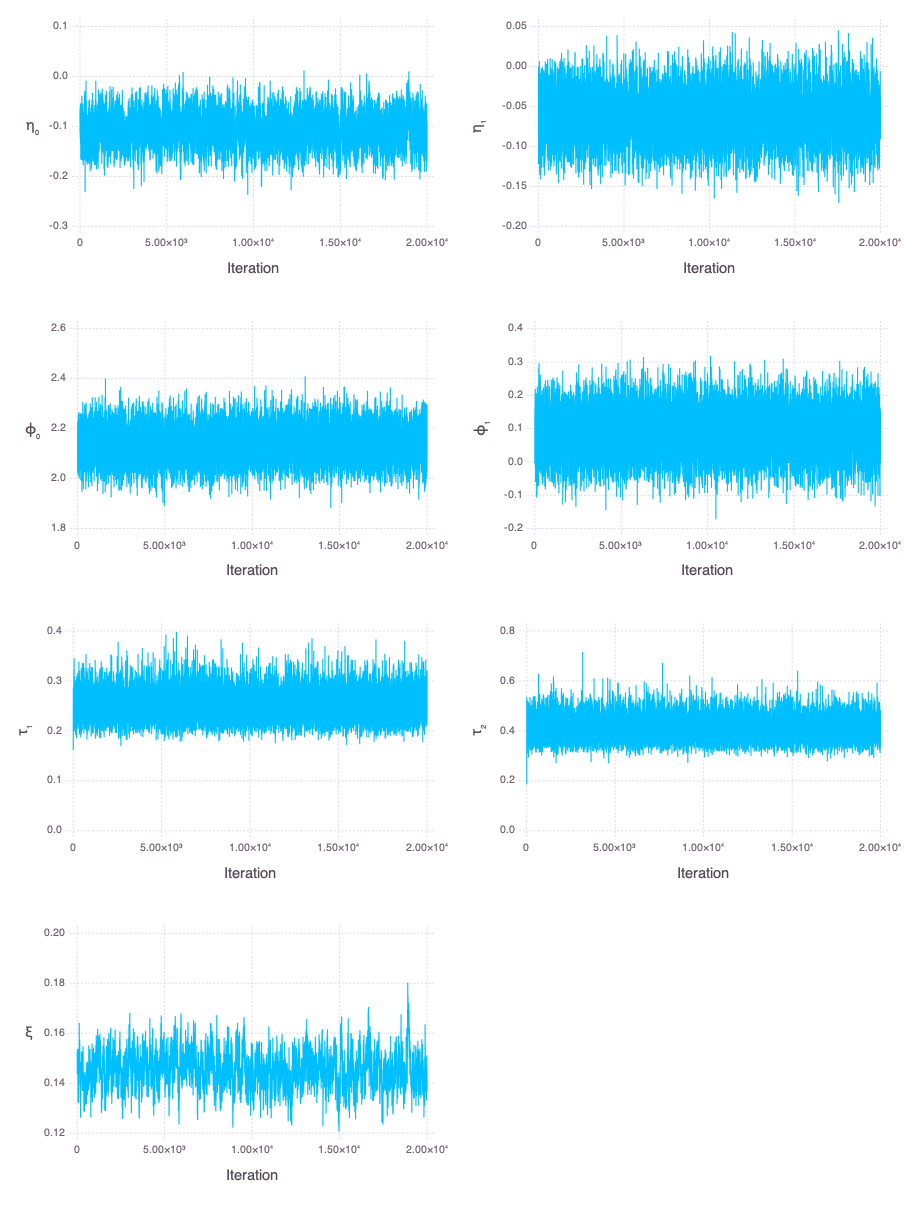

In [16]:
fig1 = plot(results, x=:Iteration, y=:η₀, Geom.line)
fig2 = plot(results, x=:Iteration, y=:η₁, Geom.line)
fig3 = plot(results, x=:Iteration, y=:ϕ₀, Geom.line)
fig4 = plot(results, x=:Iteration, y=:ϕ₁, Geom.line)
fig5 = plot(results, x=:Iteration, y=:τ₁, Geom.line)
fig6 = plot(results, x=:Iteration, y=:τ₂, Geom.line)
fig7 = plot(results, x=:Iteration, y=:ξ, Geom.line)

set_default_plot_size(24cm, 32cm)

fig = gridstack([fig1 fig2;
    fig3 fig4;
    fig5 fig6;
    fig7 Gadfly.plot()])

# draw(PDF("traces.pdf"), fig)

### Discarding the first 10,000 iterations as the warm-up

In [17]:
η = η[Not(1:10000), :]
ϕ = ϕ[Not(1:10000), :]

deleteat!(τ₁, 1:10000)
deleteat!(τ₂, 1:10000)
deleteat!(ξ, 1:10000);

### Point estimates

Defined as the posterior mean.

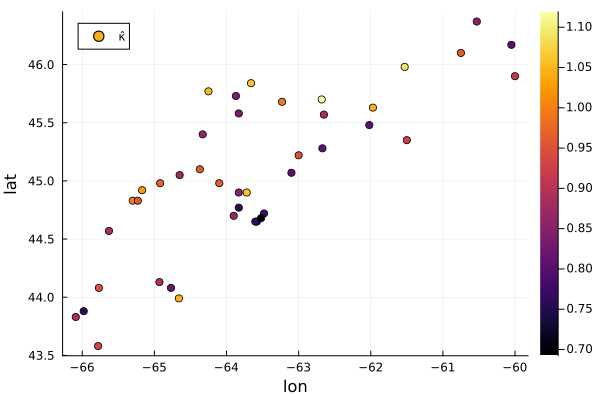

In [18]:

κ = exp.(η)
σ = exp.(ϕ)

κ̂ = vec(mean(κ, dims=1))
σ̂ = vec(mean(σ, dims=1))
        
fig = Plots.scatter(covariate.lon, covariate.lat, zcolor=κ̂, label="κ̂", xlabel="lon", ylabel="lat")
# Plots.savefig(fig, "spatial_shape_estimate.pdf")

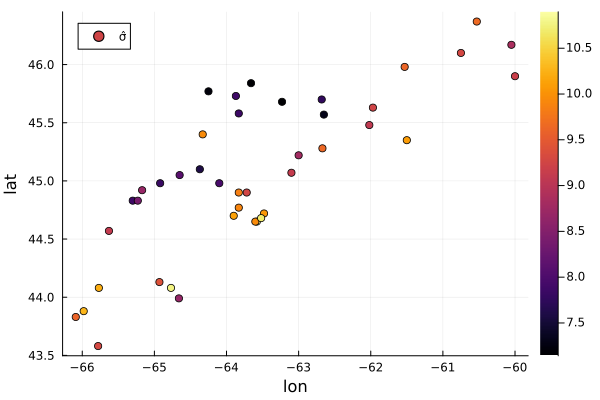

In [19]:
Plots.scatter(covariate.lon, covariate.lat, zcolor=σ̂, label="σ̂", xlabel="lon", ylabel="lat")
# Plots.savefig(fig, "spatial_scale_estimate.pdf")

### Model adequation

qqplot of station `index`

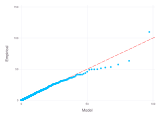

In [20]:
index = 1

# empirical quantiles

q, p = Extremes.ecdf(y[index])

κᵢ = κ[:, index]
σᵢ = σ[:,index]

fd = ExtendedGeneralizedPareto.(TBeta.(κᵢ), GeneralizedPareto.(σᵢ, ξ))

q̂ = similar(q)

for j in eachindex(p)
    
    q̂[j] = mean(quantile.(fd, p[j]))
    
end

set_default_plot_size(16cm, 12cm)

fig = Gadfly.plot(x=q̂, y=q, Geom.point, Geom.abline(color="red", style=:dash),
        Guide.xlabel("Model"), Guide.ylabel("Empirical"),
        Theme(discrete_highlight_color=c->nothing))

# draw(PDF("qqplot.pdf"), fig)